In [1]:
import os
import json
import time
from typing import TypedDict, Literal, Any

from dotenv import load_dotenv
from pydantic import BaseModel, Field, ValidationError

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI

from langgraph.graph import StateGraph, START, END

from langchain_community.tools.tavily_search import TavilySearchResults
from IPython.display import Image, display
from langsmith import traceable


C:\Users\user\AppData\Local\Temp\ipykernel_11544\2862899886.py:14: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
load_dotenv(override=True)

MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

LANGSMITH_PROJECT = os.getenv(
    "LANGSMITH_PROJECT",
    "qa-agent-phase-2"
)

# Explicitly set environment variables in os.environ for global LangSmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGSMITH_TRACING", "true")
os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING", "true")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY", "")
os.environ["LANGSMITH_ENDPOINT"] = os.getenv("LANGSMITH_ENDPOINT", "https://api.smith.langchain.com")
os.environ["LANGCHAIN_PROJECT"] = LANGSMITH_PROJECT
os.environ["LANGSMITH_PROJECT"] = LANGSMITH_PROJECT

if not MISTRAL_API_KEY:
    raise ValueError("MISTRAL_API_KEY is missing.")

if not TAVILY_API_KEY:
    raise ValueError("TAVILY_API_KEY is missing.")

print("Environment loaded successfully.")
print(f"LangSmith project: {LANGSMITH_PROJECT}")


Environment loaded successfully.
LangSmith project: doxer_ai


In [3]:
class LLMClient:

    def __init__(
        self,
        model: str = "mistral-small-latest",
        temperature: float = 0.1,
        max_retries: int = 3,
    ):
        self.model = model
        self.temperature = temperature
        self.max_retries = max_retries

        if not MISTRAL_API_KEY:
            raise ValueError(
                "MISTRAL_API_KEY is not configured."
            )

        self.llm = ChatMistralAI(
            model=model,
            temperature=temperature,
            max_retries=max_retries,
            api_key=MISTRAL_API_KEY,
        )

    @traceable(name="LLMClient.invoke")
    def invoke(self, messages):
        return self.llm.invoke(messages)

    @traceable(name="LLMClient.with_structured_output")
    def with_structured_output(self, schema):
        return self.llm.with_structured_output(schema)


llm_client = LLMClient(
    model="mistral-small-latest",
    temperature=0.1,
)

print("LLM client initialized.")


LLM client initialized.


In [4]:
class StructuredOutputNode:

    def __init__(
        self,
        llm_client: LLMClient,
        schema: type[BaseModel],
        system_prompt: str,
        max_repair_attempts: int = 1,
    ):
        self.llm_client = llm_client
        self.schema = schema
        self.system_prompt = system_prompt
        self.max_repair_attempts = max_repair_attempts

    @traceable(name="StructuredOutputNode.invoke")
    def invoke(self, user_input: str) -> BaseModel:

        structured_llm = (
            self.llm_client
            .with_structured_output(self.schema)
        )

        messages = [
            SystemMessage(
                content=self.system_prompt
            ),
            HumanMessage(
                content=user_input
            ),
        ]

        last_error = None

        for attempt in range(
            self.max_repair_attempts + 1
        ):

            try:

                response = structured_llm.invoke(
                    messages
                )

                # Depending on the provider/integration,
                # structured output may already be a Pydantic object.
                if isinstance(
                    response,
                    self.schema
                ):
                    return response

                # Explicit validation for extra safety.
                validated = self.schema.model_validate(
                    response
                )

                return validated

            except (
                ValidationError,
                ValueError,
                TypeError
            ) as error:

                last_error = error

                if attempt >= self.max_repair_attempts:
                    break

                repair_message = f"""
Your previous structured response failed validation.

Validation error:
{error}

Please correct the output and return ONLY a response
that conforms exactly to the required structured schema.

Do not explain the correction.
"""

                messages.append(
                    HumanMessage(
                        content=repair_message
                    )
                )

        raise RuntimeError(
            "Structured output failed after "
            f"{self.max_repair_attempts + 1} attempts. "
            f"Last error: {last_error}"
        )


In [5]:
class QAState(TypedDict):
    query: str
    needs_web_search: bool
    max_results: int
    search_results: list[dict]
    answer: str

In [6]:
class IntentClassification(BaseModel):
    needs_web_search: bool = Field(
        description=(
            "Whether the user's question requires current, "
            "recent, changing, or externally verifiable information."
        )
    )

    max_results: int = Field(
        default=3,
        ge=2,
        le=10,
        description=(
            "Number of web search results needed to answer the "
            "question reliably. Usually 3. Use more for complex, use less for simplest questions."
            "or multi-source questions and fewer for simple questions."
        )
    )

    reasoning: str = Field(
        description=(
            "Brief explanation of why web search is or is not required "
            "and why this number of results is appropriate."
        )
    )

In [7]:
from datetime import datetime

current_date = datetime.now().strftime("%Y-%m-%d")

current_date

'2026-08-28'

In [8]:
intent_router = StructuredOutputNode(
    llm_client=llm_client,
    schema=IntentClassification,
    system_prompt=f"""
You are the intent-classification component of a production QA system.

Your job is to determine whether a user's question requires
web search.

Use web search when:

1. The user explicitly asks for the latest, newest, current,
   today, recently, this week, or similar time-sensitive information.

2. The answer is likely to have changed since the model's
   knowledge cutoff.

3. The question asks for current software versions, APIs,
   documentation, pricing, releases, news, events, or live data.

4. The question requires factual verification from current
   external sources.

Do NOT use web search for:

1. Stable programming concepts.
2. General mathematics.
3. Basic computer science explanations.
4. General definitions.
5. Conceptual questions whose answers are unlikely to change.

For max_results:

- Default to 3.
- Use 2 for very simple factual lookups.
- Use 3 for normal questions.
- Use 4-6 when multiple sources or aspects need verification.
- Never exceed 10.

Current date: {current_date}

When interpreting temporal expressions such as "latest", "current",
"last", "recent", "today", "or any date" etc., interpret them relative to
the current date above.

The goal is to minimize unnecessary web-search cost while
providing enough sources for reliable answers.

Return only the required structured output.

"""
)

In [9]:
test_queries = [
    "What is dependency injection?",
    "What is the latest stable version of LangGraph?",
    "Who won the latest FIFA World Cup?",
    "Explain the difference between a list and tuple in Python.",
    "What is the current price of the iPhone 17?"
]

for query in test_queries:

    result = intent_router.invoke(query)

    print("=" * 70)
    print("QUERY:", query)
    print("WEB:", result.needs_web_search)
    print("MAX RESULTS:", result.max_results)
    print("REASONING:", result.reasoning)


QUERY: What is dependency injection?
WEB: False
MAX RESULTS: 3
REASONING: The question asks for a general definition of dependency injection, which is a stable programming concept unlikely to change. No web search is required.
QUERY: What is the latest stable version of LangGraph?
WEB: True
MAX RESULTS: 3
REASONING: The user is asking for the latest stable version of LangGraph, which is time-sensitive and requires current information. This necessitates a web search to verify the most up-to-date version.
QUERY: Who won the latest FIFA World Cup?
WEB: True
MAX RESULTS: 2
REASONING: The question explicitly asks for the latest FIFA World Cup winner, which is time-sensitive information that requires verification from current external sources.
QUERY: Explain the difference between a list and tuple in Python.
WEB: False
MAX RESULTS: 3
REASONING: The question is about a stable programming concept (difference between list and tuple in Python) that is unlikely to change. No web search is require

In [10]:
DEFAULT_MAX_RESULTS = 3

MIN_MAX_RESULTS = 2

MAX_MAX_RESULTS = 10


def sanitize_max_results(
    value: int | None,
    default: int = DEFAULT_MAX_RESULTS,
) -> int:
    """
    Sanitize max_results.

    Rules:
    - None -> default
    - Invalid value -> default
    - Below minimum -> minimum
    - Above maximum -> maximum
    """

    if value is None:
        value = default

    try:
        value = int(value)

    except (TypeError, ValueError):
        value = default

    return max(
        MIN_MAX_RESULTS,
        min(value, MAX_MAX_RESULTS),
    )

In [11]:
# ============================================================
# Tavily Search Client
# ============================================================

class TavilySearchClient:

    def __init__(
        self,
        api_key: str | None = None,
        timeout: int = 15,
        default_max_results: int = DEFAULT_MAX_RESULTS,
    ):
        """
        Initialize Tavily search client.

        Parameters
        ----------
        api_key:
            Tavily API key. If not provided, TAVILY_API_KEY
            is read from environment variables.

        timeout:
            Request timeout.

        default_max_results:
            Default number of search results.
        """

        self.api_key = (
            api_key
            or os.getenv("TAVILY_API_KEY")
        )

        if not self.api_key:
            raise ValueError(
                "TAVILY_API_KEY is not configured."
            )

        self.timeout = timeout

        self.default_max_results = sanitize_max_results(
            default_max_results
        )

    # ========================================================
    # Search
    # ========================================================

    def search(
        self,
        query: str,
        max_results: int | None = None,
    ) -> list[dict[str, Any]]:
        """
        Search the web using TavilySearchResults.

        max_results can be dynamically supplied by the agent.
        """

        # ----------------------------------------------------
        # Validate query
        # ----------------------------------------------------

        if not query or not query.strip():
            raise ValueError(
                "Search query cannot be empty."
            )

        # ----------------------------------------------------
        # Sanitize max_results
        # ----------------------------------------------------

        max_results = sanitize_max_results(
            max_results,
            default=self.default_max_results,
        )

        # ----------------------------------------------------
        # Create TavilySearchResults tool
        # ----------------------------------------------------

        tavily_search = TavilySearchResults(
            max_results=max_results,
            search_depth="basic",
            include_answer=False,
            include_raw_content=False,
            include_images=False,
        )

        # ----------------------------------------------------
        # Execute search
        # ----------------------------------------------------

        try:

            response = tavily_search.invoke(
                {
                    "query": query.strip()
                }
            )

        except Exception as error:

            raise RuntimeError(
                f"Tavily search failed: {error}"
            ) from error

        # ----------------------------------------------------
        # Format results
        # ----------------------------------------------------

        return self._format_results(response)

    # ========================================================
    # Format Results
    # ========================================================

    def _format_results(
        self,
        results: Any,
    ) -> list[dict[str, Any]]:
        """
        Normalize TavilySearchResults output into a
        predictable format.
        """

        # TavilySearchResults normally returns a list
        # of dictionaries.

        if not isinstance(results, list):
            return []

        formatted = []

        for index, result in enumerate(
            results,
            start=1,
        ):

            if not isinstance(result, dict):
                continue

            formatted.append(
                {
                    "id": index,

                    "title": result.get(
                        "title",
                        "",
                    ),

                    "url": result.get(
                        "url",
                        "",
                    ),

                    "content": result.get(
                        "content",
                        "",
                    ),

                    "score": result.get(
                        "score",
                    ),
                }
            )

        return formatted


In [12]:
tavily_client = TavilySearchClient(
    api_key=TAVILY_API_KEY,
    timeout=15,
    default_max_results=3,
)

print("Tavily client initialized.")


Tavily client initialized.


In [13]:
results = tavily_client.search(
    "Who won the last fifa world cup?",
    max_results=3,
)

print(f"Returned {len(results)} results.\n")

for result in results:

    print("-" * 70)
    print(f"[{result['id']}] {result['title']}")
    print(result["url"])
    print(f"Score: {result['score']}")
    print(result["content"][:500])


C:\Users\user\AppData\Local\Temp\ipykernel_11544\2405303803.py:82: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(


Returned 3 results.

----------------------------------------------------------------------
[1] Who won the last World Cup?
https://www.britannica.com/question/Who-won-the-last-World-Cup
Score: 0.8861155
On July 19, 2026, Spain beat Argentina 1–0 after extra time to win the 2026 FIFA World Cup. Spanish forward Ferran Torres scored the winning goal in extra time after coming on as a substitute during the match. Argentina won the previous FIFA World Cup, which was held in Qatar in 2022. In a stunning high-scoring final match—in which Kylian Mbappé of France became the first player since 1966 to score three goals in a final—Argentina beat out France in the World Cup’s third shoot-out victory in
----------------------------------------------------------------------
[2] Who won the last FIFA World Cup?
https://www.cbs8.com/article/sports/soccer/world-cup/who-won-last-world-cup/507-38e0e34c-dd9c-435f-ad9c-227eaa9f6d7a
Score: 0.8619225
x

Skip Navigation

 Share on Facebook
 Share on SMS
 Sha

In [14]:
def format_search_results_for_llm(
    results: list[dict]
) -> str:

    if not results:
        return "No web search results were found."

    blocks = []

    for result in results:

        block = f"""
SOURCE {result['id']}

Title:
{result['title']}

URL:
{result['url']}

Relevance score:
{result['score']}

Content:
{result['content']}
"""

        blocks.append(block.strip())

    return "\n\n".join(blocks)


In [15]:
def classify_intent(
    state: QAState
) -> dict:

    query = state["query"]

    result = intent_router.invoke(
        query
    )

    max_results = sanitize_max_results(
        result.max_results
    )

    return {
        "needs_web_search": result.needs_web_search,
        "max_results": max_results,
        "search_results": [],
    }


In [16]:
def route_after_classification(
    state: QAState
) -> Literal[
    "answer_direct",
    "web_search"
]:

    if state["needs_web_search"]:
        return "web_search"

    return "answer_direct"


In [17]:
def answer_direct(
    state: QAState
) -> dict:

    query = state["query"]

    messages = [
        SystemMessage(
            content="""
You are a helpful technical QA assistant.

Answer the user's question accurately and clearly.

The question has been classified as not requiring
web search.

Do not claim that you searched the web.
"""
        ),
        HumanMessage(
            content=query
        ),
    ]

    response = llm_client.invoke(
        messages
    )

    return {
        "answer": response.content
    }

In [18]:
def web_search(
    state: QAState
) -> dict:

    query = state["query"]

    max_results = sanitize_max_results(
        state.get(
            "max_results",
            DEFAULT_MAX_RESULTS
        )
    )

    results = tavily_client.search(
        query=query,
        max_results=max_results,
    )

    return {
        "search_results": results
    }

In [21]:
def synthesize(
    state: QAState
) -> dict:

    query = state["query"]

    search_context = (
        format_search_results_for_llm(
            state["search_results"]
        )
    )

    prompt = f"""
You are a research-backed QA assistant.

Answer the user's question using the web search
results provided below.

<USER_QUERY>
{query}
</USER_QUERY>

<WEB_SEARCH_CONTEXT>
{search_context}
</WEB_SEARCH_CONTEXT>

Instructions:

1. Answer the question directly.
2. Use the provided sources as evidence. 
3. Do not invent facts that are not supported by the sources.
4. If sources disagree, acknowledge the disagreement.
5. Cite sources inline using [1], [2], [3], etc.
6. Only cite sources that actually support the claim.
7. At the end, provide a "Sources" section containing
   the source number, title, and URL.
"""

    messages = [
        
        SystemMessage(
            content=f"""
You are a precise web-grounded QA assistant.

Current date: {current_date}

When interpreting temporal expressions such as "latest", "current",
"last", "recent", "today", "or any date" etc., interpret them relative to
the current date above.
"""
        ),
        HumanMessage(
            content=prompt
        ),
    ]

    response = llm_client.invoke(
        messages
    )

    return {
        "answer": response.content
    }


In [22]:
builder = StateGraph(QAState)

builder.add_node(
    "classify_intent",
    classify_intent
)

builder.add_node(
    "answer_direct",
    answer_direct
)

builder.add_node(
    "web_search",
    web_search
)

builder.add_node(
    "synthesize",
    synthesize
)

In [23]:
builder.add_edge(
    START,
    "classify_intent"
)

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    {
        "answer_direct": "answer_direct",
        "web_search": "web_search",
    }
)

builder.add_edge(
    "answer_direct",
    END
)

builder.add_edge(
    "web_search",
    "synthesize"
)

builder.add_edge(
    "synthesize",
    END
)

Phase 2 graph compiled successfully.


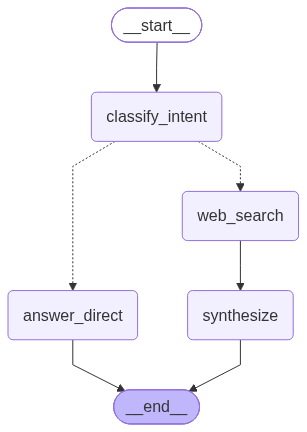

In [24]:
qa_graph = builder.compile()

print("Phase 2 graph compiled successfully.")
qa_graph


In [25]:
def create_initial_state(
    query: str
) -> QAState:

    return {
        "query": query,
        "needs_web_search": False,
        "max_results": DEFAULT_MAX_RESULTS,
        "search_results": [],
        "answer": "",
    }

In [34]:
query = "What is dependency injection?"

initial_state = create_initial_state(
    query
)

result = qa_graph.invoke(
    initial_state
)

print(result["answer"])

**Dependency Injection (DI)** is a design pattern and a fundamental concept in software engineering where an object receives its dependencies (services or other objects it depends on) from an external source rather than creating them itself. This promotes loose coupling, reusability, and easier testing.

### Key Concepts:
1. **Dependency**: An object that another object requires to function (e.g., a service, repository, or configuration).
2. **Injection**: The process of providing the dependency to the dependent object, typically through:
   - **Constructor Injection**: Dependencies are passed via the class constructor.
   - **Setter Injection**: Dependencies are set via setter methods.
   - **Interface Injection**: The dependency implements an interface to inject itself.

### Example (Constructor Injection in Java):
```java
// Dependency
class DatabaseService {
    public void saveData() {
        System.out.println("Data saved to database.");
    }
}

// Dependent class (with DI)
cla

In [35]:
result['search_results']

[]

In [36]:
query = "Give me the stats of last test match between pakistan and england"

initial_state = create_initial_state(
    query
)

result = qa_graph.invoke(
    initial_state
)

print("Web search:", result["needs_web_search"])
print("Max results:", result["max_results"])
print("Results:", len(result["search_results"]))

print("\nANSWER:\n")
print(result["answer"])

Web search: True
Max results: 3
Results: 3

ANSWER:

The last Test match between Pakistan and England was the **1st Test of the England in Pakistan series in Multan** (as of the latest available data). Here are the key stats:

- **Result:** England won by an innings and 47 runs [3].
- **England 1st Innings:** 823/7 declared (150 overs) [3].
- **Pakistan 2nd Innings:** 220 all out (54.5 overs) [3].

### Sources:
1. **England vs Pakistan Cricket Head To Head, Score & Record - AiScore**
   [https://m.aiscore.com/head-to-head/cricket/england-vs-pakistan](https://m.aiscore.com/head-to-head/cricket/england-vs-pakistan)

2. **A look at the Pakistan vs England Test series stats since 2005 - Threads**
   [https://www.threads.com/@cricinsider01/post/DcI5WRnjZKB/a-look-at-the-pakistan-vs-england-test-series-stats-since-pa-kveng-cricket-stats](https://www.threads.com/@cricinsider01/post/DcI5WRnjZKB/a-look-at-the-pakistan-vs-england-test-series-stats-since-pa-kveng-cricket-stats)

3. **Pakistan vs 

In [26]:

llm_client = ChatMistralAI(
    model="mistral-small-latest",
    temperature=0.1,
    timeout=60,
)


def answer_node(state: QAState) -> dict:

    query = state["query"]

    prompt = f"""
You are a helpful technical assistant.

Answer the user's question clearly and accurately.

User question:
{query}
"""

    response = llm_client.invoke(prompt)

    return {
        "answer": response.content
    }


In [28]:
from langgraph.graph import StateGraph, START, END


def build_graph():

    builder = StateGraph(QAState)

    builder.add_node(
        "answer_node",
        answer_node
    )

    builder.add_edge(
        START,
        "answer_node"
    )

    builder.add_edge(
        "answer_node",
        END
    )

    return builder.compile()


graph = build_graph()

In [29]:
graph

In [30]:
result = graph.invoke(
    {
        "query": "What is prompt injection?",
        "answer": "",
    }
)

print(result)

{'query': 'What is prompt injection?', 'answer': '**Prompt Injection** is a type of security vulnerability in AI systems, particularly in large language models (LLMs) and AI-powered applications that rely on user-provided instructions (prompts). It occurs when an attacker manipulates the input prompt to override or bypass the intended behavior of the AI, leading to unintended actions, data leaks, or unauthorized access.\n\n### **How Prompt Injection Works:**\n1. **Malicious Input:** An attacker crafts a prompt that tricks the AI into ignoring its original instructions or performing unintended tasks.\n2. **Bypass Safeguards:** The AI may be designed to follow certain rules (e.g., "Do not reveal sensitive data"), but the injected prompt overrides these constraints.\n3. **Unintended Output:** The AI may comply with the attacker’s request, such as leaking private information, executing harmful commands, or generating misleading responses.\n\n### **Example of Prompt Injection:**\n- **Origin